# Klasifikasi Konsentrasi Boraks pada Kertas Kurkumin

Notebook ini melatih model deep learning untuk mengklasifikasikan konsentrasi boraks dari gambar ESP32-CAM. Alur utama: segmentasi area kertas kurkumin, preprocessing, split data, training MobileNetV2, evaluasi, baseline RGB, dan prediksi gambar baru.

## 1. Instalasi Library

Jalankan cell ini jika muncul error seperti `ModuleNotFoundError: No module named 'cv2'`. Setelah instalasi selesai, restart kernel Jupyter lalu jalankan notebook dari awal.

In [19]:
import sys

# cv2 berasal dari package opencv-python.
# Jalankan cell ini jika dependency belum terpasang di kernel Jupyter.
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


## 2. Import Library dan Konfigurasi Dataset

Ubah `DATASET_DIR` jika folder dataset berada di lokasi berbeda.

In [20]:
import os
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

DATASET_SOURCE_DIR = "dataset"
RANGE_DATASET_DIR = "dataset_range"
DATASET_DIR = DATASET_SOURCE_DIR
MODEL_OUTPUT = "borax_cnn_model.h5"
IMG_SIZE = (128, 128)
RANDOM_STATE = 42
BATCH_SIZE = 16
EPOCHS = 100

CLASS_NAMES = [
    "0ppm", "100ppm", "250ppm", "500ppm", "750ppm",
    "1000ppm", "1250ppm", "1500ppm", "1750ppm", "2000ppm",
]

# ================= PERUBAHAN UTAMA =================
# Sekarang 5 kelas rentang: 0ppm, 100-250, 500-1000, 1250-1500, 1750-2000
USE_RANGE_LABELS = True
RANGE_CLASS_NAMES = [
    "0ppm",
    "100-250ppm",
    "500-1000ppm",
    "1250-1500ppm",
    "1750-2000ppm"
]
ORIGINAL_TO_RANGE = {
    "0ppm": "0ppm",
    "100ppm": "100-250ppm",
    "250ppm": "100-250ppm",
    "500ppm": "500-1000ppm",
    "750ppm": "500-1000ppm",
    "1000ppm": "500-1000ppm",
    "1250ppm": "1250-1500ppm",
    "1500ppm": "1250-1500ppm",
    "1750ppm": "1750-2000ppm",
    "2000ppm": "1750-2000ppm",
}
# ===================================================

ACTIVE_CLASS_NAMES = RANGE_CLASS_NAMES if USE_RANGE_LABELS else CLASS_NAMES

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("Dataset sumber:", Path(DATASET_SOURCE_DIR).resolve())
print("Mode label:", "rentang (5 kelas)" if USE_RANGE_LABELS else "10 kelas asli")
print("Label aktif:", ACTIVE_CLASS_NAMES)

def prepare_range_dataset(source_dir=DATASET_SOURCE_DIR, output_dir=RANGE_DATASET_DIR):
    source_dir = Path(source_dir)
    output_dir = Path(output_dir)
    if not source_dir.exists():
        raise FileNotFoundError(f"Dataset sumber tidak ditemukan: {source_dir}")

    # Hapus folder output lama jika ingin memulai dari awal (optional, komentari jika tidak perlu)
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Buat subfolder untuk setiap kelas rentang
    for range_name in RANGE_CLASS_NAMES:
        (output_dir / range_name).mkdir(parents=True, exist_ok=True)

    copied = 0
    for original_name, range_name in ORIGINAL_TO_RANGE.items():
        original_dir = source_dir / original_name
        if not original_dir.exists():
            print(f"Skip, folder tidak ada: {original_dir}")
            continue
        target_dir = output_dir / range_name
        for image_path in original_dir.iterdir():
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                target_path = target_dir / image_path.name
                # Hindari duplikasi (jika nama file sama, tambahkan suffix)
                if target_path.exists():
                    stem = target_path.stem
                    suffix = target_path.suffix
                    counter = 1
                    while target_path.exists():
                        target_path = target_dir / f"{stem}_{counter}{suffix}"
                        counter += 1
                shutil.copy2(image_path, target_path)
                copied += 1
    return copied

if USE_RANGE_LABELS:
    copied = prepare_range_dataset()
    DATASET_DIR = RANGE_DATASET_DIR
    print(f"Dataset rentang siap: {Path(DATASET_DIR).resolve()}")
    print(f"File baru disalin: {copied}")
else:
    DATASET_DIR = DATASET_SOURCE_DIR
    print(f"Memakai dataset asli: {Path(DATASET_DIR).resolve()}")

# Hitung jumlah gambar per kelas
class_counts = []
for class_name in ACTIVE_CLASS_NAMES:
    class_dir = Path(DATASET_DIR) / class_name
    count = 0
    if class_dir.exists():
        count = sum(1 for path in class_dir.iterdir() if path.suffix.lower() in IMAGE_EXTENSIONS)
    class_counts.append({"kelas": class_name, "jumlah_gambar": count})

class_counts_df = pd.DataFrame(class_counts)
display(class_counts_df)
print("Total gambar:", int(class_counts_df["jumlah_gambar"].sum()))

TensorFlow: 2.21.0
Dataset sumber: C:\Users\LENOVO\Documents\project\detection-boraks-esp32cam\detection-boraks-esp32cam\dataset
Mode label: rentang (5 kelas)
Label aktif: ['0ppm', '100-250ppm', '500-1000ppm', '1250-1500ppm', '1750-2000ppm']
Dataset rentang siap: C:\Users\LENOVO\Documents\project\detection-boraks-esp32cam\detection-boraks-esp32cam\dataset_range
File baru disalin: 160


,kelas,jumlah_gambar
0,0ppm,16
1,100-250ppm,32
2,500-1000ppm,48
3,1250-1500ppm,32
4,1750-2000ppm,32


Total gambar: 160


## 5. Fungsi Segmentasi Otomatis Kertas Kurkumin

Gambar dikonversi ke HSV, lalu area kertas dicari dengan threshold warna kurkumin yang dibuat lebih lebar. Dataset ini memuat kertas kuning pada 0ppm dan area reaksi oranye/coklat pada ppm tinggi, sehingga threshold `H: 20-40` saja terlalu sempit. Notebook memakai rentang utama `H: 8-70, S: 35-255, V: 35-255`, lalu kontur terbesar dianggap sebagai area kertas. Jika kontur tidak ditemukan, notebook memakai fallback crop tengah.

In [21]:
def center_crop(image_bgr, ratio=0.6):
    height, width = image_bgr.shape[:2]
    crop_w = int(width * ratio)
    crop_h = int(height * ratio)
    x1 = max((width - crop_w) // 2, 0)
    y1 = max((height - crop_h) // 2, 0)
    return image_bgr[y1:y1 + crop_h, x1:x1 + crop_w]


def segment_curcumin_paper(image_bgr, output_size=IMG_SIZE, return_mask=False):
    """
    Segmentasi area kertas kurkumin menggunakan kombinasi:
    1. Konversi ke HSV, ambil channel Saturation (nilai tinggi untuk area berwarna)
    2. Threshold adaptif Otsu pada channel S
    3. Morfologi untuk membersihkan noise
    4. Ambil kontur terbesar (dengan asumsi kertas adalah objek terluas dalam frame)
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    s_channel = hsv[:, :, 1]  # saturation channel
    
    # Threshold Otsu (adaptive)
    _, thresh = cv2.threshold(s_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Morfologi: tutup lubang kecil, buang noise
    kernel = np.ones((5,5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # Cari kontur
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        # fallback: crop tengah 70%
        h, w = image_bgr.shape[:2]
        ch, cw = int(h*0.7), int(w*0.7)
        y1 = (h - ch)//2
        x1 = (w - cw)//2
        crop = image_bgr[y1:y1+ch, x1:x1+cw]
        bbox = None
    else:
        # Ambil kontur terbesar (area)
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        if area < 500:  # jika terlalu kecil, fallback
            return segment_curcumin_paper(image_bgr, output_size, return_mask, fallback=True)
        x, y, w, h = cv2.boundingRect(largest)
        # Beri padding 5% agar tidak terpotong
        pad = int(0.05 * max(w, h))
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(image_bgr.shape[1], x + w + pad)
        y2 = min(image_bgr.shape[0], y + h + pad)
        crop = image_bgr[y1:y2, x1:x2]
        bbox = (x1, y1, x2-x1, y2-y1)
    
    if output_size:
        crop = cv2.resize(crop, output_size, interpolation=cv2.INTER_AREA)
    
    if return_mask:
        # mask dari thresh setelah morfologi
        return crop, thresh, bbox
    return crop


def to_active_label(label_name):
    if label_name in ACTIVE_CLASS_NAMES:
        return label_name
    if USE_RANGE_LABELS:
        return ORIGINAL_TO_RANGE[label_name]
    return label_name


def iter_dataset_images(dataset_dir):
    dataset_dir = Path(dataset_dir)
    expected_folders = ACTIVE_CLASS_NAMES if USE_RANGE_LABELS else CLASS_NAMES
    for class_name in expected_folders:
        class_dir = dataset_dir / class_name
        if not class_dir.exists():
            print(f"Warning: class folder not found: {class_dir}")
            continue
        active_label = to_active_label(class_name)
        class_index = ACTIVE_CLASS_NAMES.index(active_label)
        for path in sorted(class_dir.iterdir()):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                yield path, class_index, class_name

## 6. Verifikasi Visual Hasil Segmentasi

Cell ini menampilkan gambar asli, mask HSV, dan hasil crop 128x128. Bagian ini penting untuk memastikan model benar-benar fokus pada kertas, bukan background.

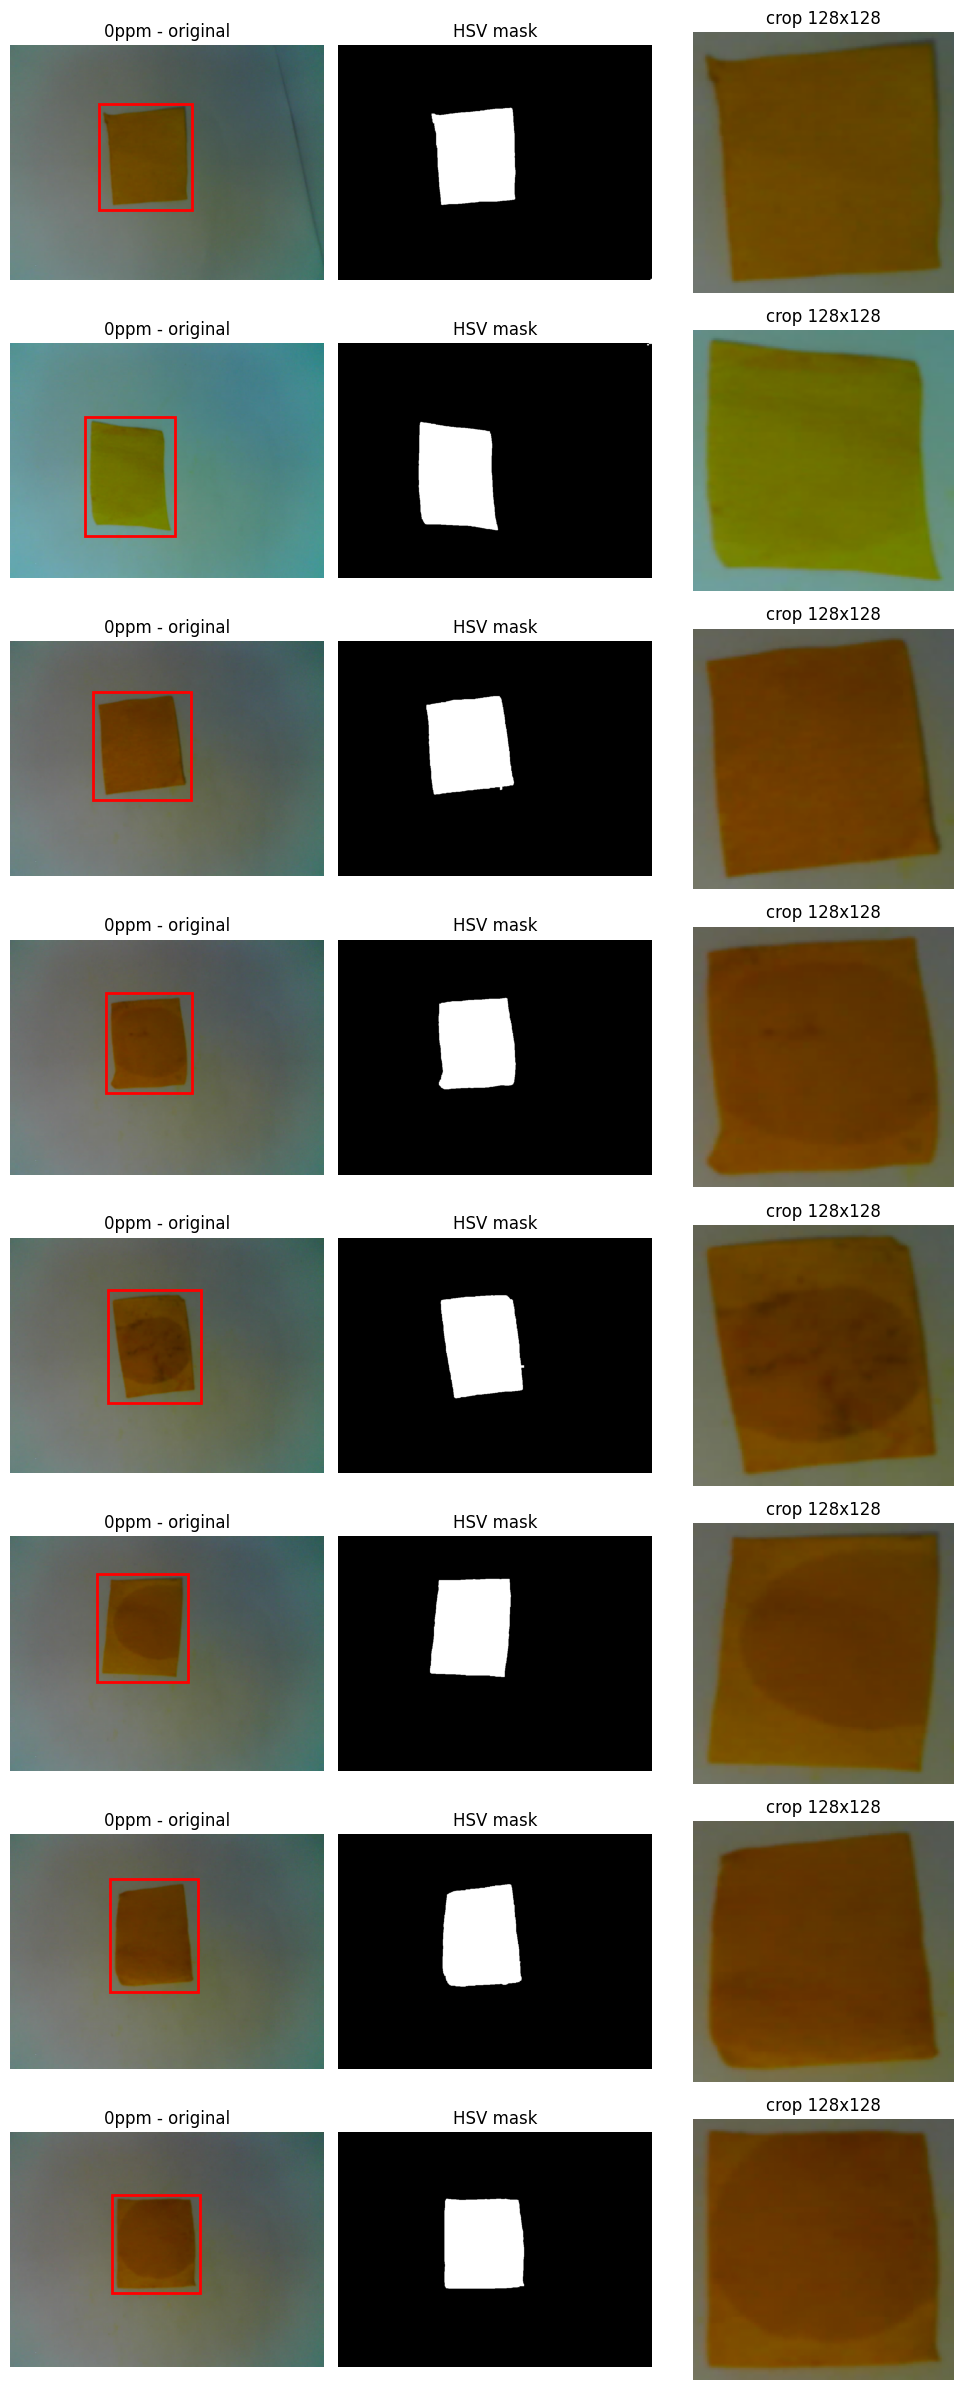

In [22]:
def show_segmentation_examples(dataset_dir, max_examples=8):
    examples = []
    for image_path, _, class_name in iter_dataset_images(dataset_dir):
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            continue
        crop_bgr, mask, bbox = segment_curcumin_paper(image_bgr, return_mask=True)
        original_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        examples.append((original_rgb, mask, crop_rgb, class_name, image_path.name, bbox))
        if len(examples) >= max_examples:
            break

    fig, axes = plt.subplots(len(examples), 3, figsize=(10, 3 * len(examples)))
    if len(examples) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, (original, mask, crop, class_name, filename, bbox) in enumerate(examples):
        axes[row, 0].imshow(original)
        axes[row, 0].set_title(f"{class_name} - original")
        if bbox:
            x, y, w, h = bbox
            axes[row, 0].add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor="red", linewidth=2))
        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title("HSV mask")
        axes[row, 2].imshow(crop)
        axes[row, 2].set_title("crop 128x128")
        for col in range(3):
            axes[row, col].axis("off")
    plt.tight_layout()
    plt.show()


show_segmentation_examples(DATASET_DIR)

## 7. Audit Kualitas Segmentasi

Sebelum training, cek berapa gambar yang berhasil ditemukan kontur kertasnya dan seberapa besar area crop terhadap gambar asli. Jika banyak fallback atau area terlalu kecil/besar, akurasi model biasanya ikut turun.

In [23]:
def audit_segmentation(dataset_dir):
    rows = []
    for image_path, _, class_name in iter_dataset_images(dataset_dir):
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            continue
        # Panggil segmentasi dengan return_mask=True, output_size=None agar tidak mengubah ukuran crop
        crop, mask, bbox = segment_curcumin_paper(image_bgr, output_size=None, return_mask=True)
        h_img, w_img = image_bgr.shape[:2]
        if bbox:
            x, y, w, h = bbox
            area_ratio = (w * h) / (w_img * h_img)
            # Hitung jumlah piksel mask dalam bounding box (pixel area kertas)
            mask_pixels = int(np.count_nonzero(mask[y:y+h, x:x+w]))
            status = "detected"
        else:
            area_ratio = np.nan
            mask_pixels = int(np.count_nonzero(mask))
            status = "fallback"
        rows.append({
            "filename": image_path.name,
            "kelas": class_name,
            "status": status,
            "area_ratio": area_ratio,
            "mask_pixels": mask_pixels,
        })
    return pd.DataFrame(rows)

seg_audit_df = audit_segmentation(DATASET_DIR)
display(seg_audit_df.groupby(["kelas", "status"]).size().unstack(fill_value=0))
display(seg_audit_df.groupby("kelas")[["area_ratio", "mask_pixels"]].mean())
print("Fallback count:", int((seg_audit_df["status"] == "fallback").sum()))

status,detected
kelas,
0ppm,16
100-250ppm,32
1250-1500ppm,32
1750-2000ppm,32
500-1000ppm,48


,area_ratio,mask_pixels
kelas,,
0ppm,0.136767,76123.937500
100-250ppm,0.161018,81356.562500
1250-1500ppm,0.160297,79217.625000
1750-2000ppm,0.147327,76916.937500
500-1000ppm,0.165329,80046.354167


Fallback count: 0


## 8. Load Dataset dan Split Stratified 70/15/15

Setiap gambar disegmentasi, diresize ke 128x128, dinormalisasi ke rentang 0-1, lalu dibagi menjadi training, validation, dan testing dengan stratify label.

In [24]:
def load_image_dataset(dataset_dir):
    images, labels, paths = [], [], []
    for image_path, class_index, class_name in iter_dataset_images(dataset_dir):
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            print(f"Skip unreadable image: {image_path}")
            continue
        crop_bgr = segment_curcumin_paper(image_bgr)
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        images.append(crop_rgb.astype("float32") / 255.0)
        labels.append(class_index)
        paths.append(str(image_path))

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)
    paths = np.array(paths)
    if len(images) == 0:
        raise RuntimeError(f"No images loaded from dataset: {dataset_dir}")
    return images, labels, paths


def extract_rgb_features_from_image(image_rgb):
    if image_rgb.dtype not in (np.float32, np.float64):
        image_rgb = image_rgb.astype("float32") / 255.0

    means = image_rgb.mean(axis=(0, 1))
    stds = image_rgb.std(axis=(0, 1))
    percentiles = np.percentile(image_rgb, [25, 50, 75], axis=(0, 1)).reshape(-1)
    hist_features = []
    for c in range(3):
        hist, _ = np.histogram(image_rgb[:, :, c], bins=8, range=(0.0, 1.0))
        hist_features.append(hist.astype("float32"))
    hist_features = np.concatenate(hist_features)
    return np.concatenate([means, stds, percentiles, hist_features])


def load_rgb_features(dataset_dir):
    features, labels, paths = [], [], []
    for image_path, class_index, class_name in iter_dataset_images(dataset_dir):
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            print(f"Skip unreadable image: {image_path}")
            continue
        crop_bgr = segment_curcumin_paper(image_bgr)
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        feat = extract_rgb_features_from_image(crop_rgb)
        features.append(feat)
        labels.append(class_index)
        paths.append(str(image_path))

    features = np.array(features, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)
    paths = np.array(paths)
    if len(features) == 0:
        raise RuntimeError(f"No features loaded from dataset: {dataset_dir}")
    return features, labels, paths


x_images, y, paths = load_image_dataset(DATASET_DIR)
x_train, x_temp, y_train, y_temp, paths_train, paths_temp = train_test_split(
    x_images, y, paths, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
x_val, x_test, y_val, y_test, paths_val, paths_test = train_test_split(
    x_temp, y_temp, paths_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("Total:", len(x_images))
print("Train:", len(x_train), "Validation:", len(x_val), "Test:", len(x_test))
print("Image shape:", x_train.shape[1:])

split_df = pd.DataFrame({
    "kelas": ACTIVE_CLASS_NAMES,
    "train": [int(np.sum(y_train == i)) for i in range(len(ACTIVE_CLASS_NAMES))],
    "validation": [int(np.sum(y_val == i)) for i in range(len(ACTIVE_CLASS_NAMES))],
    "test": [int(np.sum(y_test == i)) for i in range(len(ACTIVE_CLASS_NAMES))],
})
display(split_df)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(ACTIVE_CLASS_NAMES)),
    y=y_train,
)
class_weight = {index: float(weight) for index, weight in enumerate(weights)}
print("Class weight:", class_weight)

Total: 160
Train: 112 Validation: 24 Test: 24
Image shape: (128, 128, 3)


,kelas,train,validation,test
0,0ppm,11,2,3
1,100-250ppm,23,5,4
2,500-1000ppm,34,7,7
3,1250-1500ppm,22,5,5
4,1750-2000ppm,22,5,5


Class weight: {0: 2.036363636363636, 1: 0.9739130434782609, 2: 0.6588235294117647, 3: 1.018181818181818, 4: 1.018181818181818}


## 9. Data Augmentation Aman Warna

Augmentasi hanya rotasi kecil, translasi, dan flip horizontal. Tidak ada brightness, contrast, hue, atau augmentasi lain yang mengubah informasi warna.

In [25]:
def color_safe_augmentation():
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomRotation(5 / 360),
            tf.keras.layers.RandomTranslation(0.1, 0.1),
            tf.keras.layers.RandomFlip("horizontal"),
        ],
        name="color_safe_augmentation",
    )

## 10. Arsitektur Model

Model utama menggunakan MobileNetV2 dengan `weights='imagenet'`, `include_top=False`, dan semua layer base model dibekukan. Custom CNN ringan tersedia sebagai pembanding, tetapi MobileNetV2 lebih diprioritaskan untuk dataset kecil.

In [26]:
def build_mobilenetv2_model(num_classes):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE[1], IMG_SIZE[0], 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 3))
    x = color_safe_augmentation()(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs, name="borax_mobilenetv2")


def build_light_cnn_model(num_classes):
    return tf.keras.Sequential(
        [
            tf.keras.Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 3)),
            color_safe_augmentation(),
            tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(num_classes, activation="softmax"),
        ],
        name="borax_light_cnn",
    )


ARCHITECTURE = "light_cnn"  # pilih "mobilenetv2" atau "light_cnn"
model = build_mobilenetv2_model(len(ACTIVE_CLASS_NAMES)) if ARCHITECTURE == "mobilenetv2" else build_light_cnn_model(len(ACTIVE_CLASS_NAMES))
model.summary()

Model: "borax_light_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ color_safe_augmentation         │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,190,789 (8.36 MB)

 Trainable params: 2,190,789 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

## 11. Compile dan Training Model

Optimizer Adam memakai learning rate 0.0001. Callback EarlyStopping dan ReduceLROnPlateau dipakai untuk mengurangi risiko overfitting.

In [27]:
# Pastikan direktori models bisa ditulisi (opsional, jika ingin menyimpan model nanti)
import os
os.makedirs("models", exist_ok=True)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Callback tanpa ModelCheckpoint (untuk menghindari error OSError)
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, monitor="val_loss"),
]

# Hitung class_weight dari y_train (jika distribusi tidak seimbang)
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {c: w for c, w in zip(classes, class_weights)}
print("Class weight:", class_weight)

# Training
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,          # Output lebih ringkas
    class_weight=class_weight,
)

# Simpan model setelah training selesai (manual)
model.save("models/best_borax_model.h5")
print(f"Model saved to models/best_borax_model.h5")

Class weight: {np.int64(0): np.float64(2.036363636363636), np.int64(1): np.float64(0.9739130434782609), np.int64(2): np.float64(0.6588235294117647), np.int64(3): np.float64(1.018181818181818), np.int64(4): np.float64(1.018181818181818)}
Epoch 1/100
7/7 - 4s - 636ms/step - accuracy: 0.1161 - loss: 1.6324 - val_accuracy: 0.2083 - val_loss: 1.5964 - learning_rate: 1.0000e-04
Epoch 2/100
7/7 - 1s - 208ms/step - accuracy: 0.2232 - loss: 1.6099 - val_accuracy: 0.2500 - val_loss: 1.5964 - learning_rate: 1.0000e-04
Epoch 3/100
7/7 - 1s - 198ms/step - accuracy: 0.2589 - loss: 1.6054 - val_accuracy: 0.2917 - val_loss: 1.5974 - learning_rate: 1.0000e-04
Epoch 4/100
7/7 - 1s - 203ms/step - accuracy: 0.3214 - loss: 1.6024 - val_accuracy: 0.3333 - val_loss: 1.5936 - learning_rate: 1.0000e-04
Epoch 5/100
7/7 - 1s - 193ms/step - accuracy: 0.2857 - loss: 1.6030 - val_accuracy: 0.3333 - val_loss: 1.5901 - learning_rate: 1.0000e-04
Epoch 6/100
7/7 - 1s - 208ms/step - accuracy: 0.3571 - loss: 1.5947 - val

Model saved to models/best_borax_model.h5


## 12. Plot Accuracy dan Loss

Grafik ini dipakai untuk melihat apakah model mulai overfitting atau underfitting.

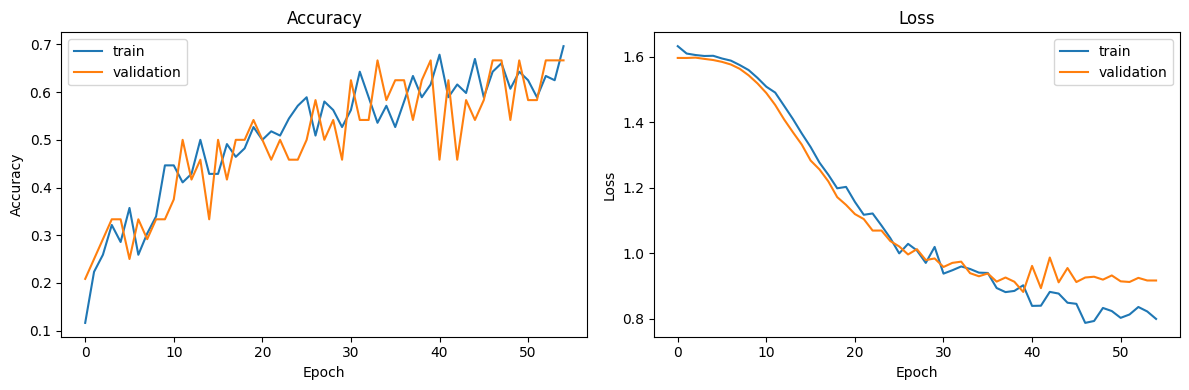

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

## 13. Evaluasi pada Data Test

Bagian ini menampilkan akurasi test, classification report, dan confusion matrix dengan label konsentrasi asli.

Test loss: 1.0309
Test accuracy: 0.5000
              precision    recall  f1-score   support

        0ppm       0.50      0.67      0.57         3
  100-250ppm       0.33      0.25      0.29         4
 500-1000ppm       0.62      0.71      0.67         7
1250-1500ppm       0.33      0.20      0.25         5
1750-2000ppm       0.50      0.60      0.55         5

    accuracy                           0.50        24
   macro avg       0.46      0.49      0.46        24
weighted avg       0.47      0.50      0.48        24

Within-1-class accuracy: 0.9583


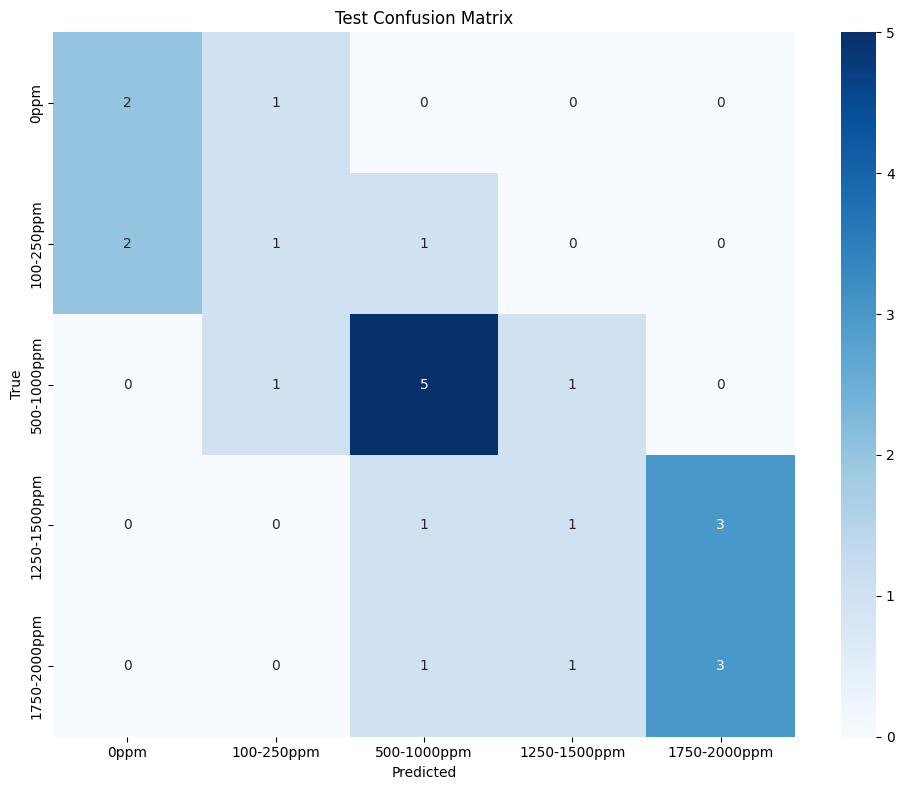

In [36]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

probabilities = model.predict(x_test, verbose=0)
y_pred = np.argmax(probabilities, axis=1)

print(classification_report(y_test, y_pred, target_names=ACTIVE_CLASS_NAMES, zero_division=0))

# Karena kelas ppm bersifat berurutan, metrik toleransi 1 level berguna untuk melihat
# apakah model salah jauh atau hanya tertukar dengan konsentrasi yang berdekatan.
within_one_step = np.mean(np.abs(y_test - y_pred) <= 1)
print(f"Within-1-class accuracy: {within_one_step:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=list(range(len(ACTIVE_CLASS_NAMES))))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ACTIVE_CLASS_NAMES, yticklabels=ACTIVE_CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 14. Contoh Prediksi 5 Gambar Test

Cell ini menampilkan gambar test, label asli, prediksi model, dan confidence.

2000ppm_20260607_182014_825.jpg | true=1750-2000ppm pred=1250-1500ppm confidence=0.5486
1000ppm_20260607_161445_658.jpg | true=500-1000ppm pred=500-1000ppm confidence=0.3364
0ppm_20260607_184104_597.jpg | true=0ppm pred=100-250ppm confidence=0.5168
1500ppm_20260607_170803_742.jpg | true=1250-1500ppm pred=1750-2000ppm confidence=0.6179
0ppm_20260607_184323_861.jpg | true=0ppm pred=0ppm confidence=0.5355


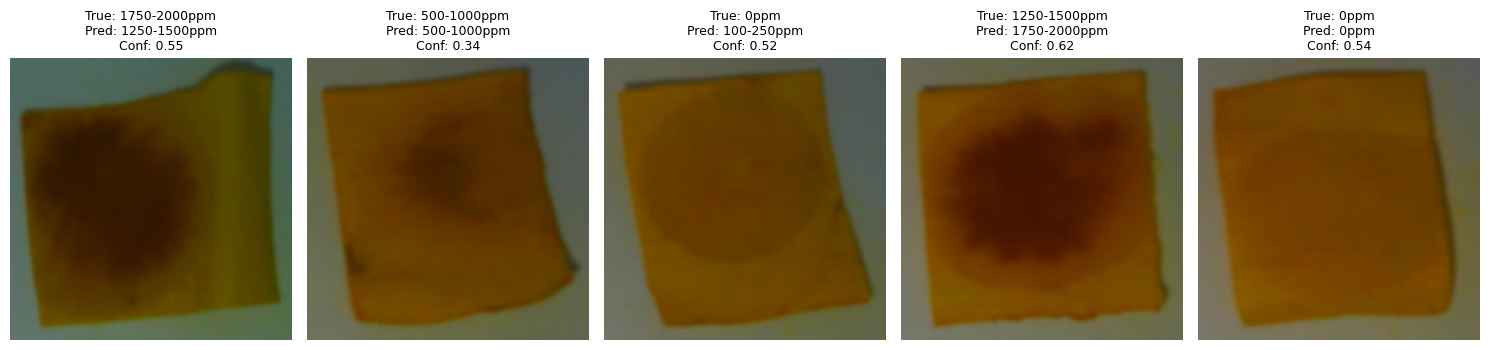

In [37]:
# Pilih indeks acak dari data test
num_samples = min(5, len(x_test))
random_indices = np.random.choice(len(x_test), num_samples, replace=False)

fig, axes = plt.subplots(1, num_samples, figsize=(3 * num_samples, 3.5))
if num_samples == 1:
    axes = [axes]

for i, idx in enumerate(random_indices):
    confidence = probabilities[idx, y_pred[idx]]
    axes[i].imshow(x_test[idx])
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {ACTIVE_CLASS_NAMES[y_test[idx]]}\nPred: {ACTIVE_CLASS_NAMES[y_pred[idx]]}\nConf: {confidence:.2f}",
        fontsize=9,
    )
    print(
        f"{Path(paths_test[idx]).name} | true={ACTIVE_CLASS_NAMES[y_test[idx]]} "
        f"pred={ACTIVE_CLASS_NAMES[y_pred[idx]]} confidence={confidence:.4f}"
    )

plt.tight_layout()
plt.show()
plt.show()

## 15. Ekstraksi RGB Rata-Rata sebagai Baseline

Fitur RGB dihitung dari area kertas yang sudah disegmentasi. Hasil disimpan ke `rgb_features.csv` dengan kolom `filename`, `kelas`, `R_mean`, `G_mean`, dan `B_mean`.

In [38]:
def extract_rgb_features(dataset_dir, output_csv="rgb_features.csv"):
    rows = []
    channel_names = ["R", "G", "B"]
    percentile_values = [25, 50, 75]
    histogram_bins = list(range(8))

    feature_names = []
    feature_names += [f"{ch}_mean" for ch in channel_names]
    feature_names += [f"{ch}_std" for ch in channel_names]
    feature_names += [f"{ch}_p{p}" for p in percentile_values for ch in channel_names]
    feature_names += [f"{ch}_hist{b}" for ch in channel_names for b in histogram_bins]

    for image_path, _, class_name in iter_dataset_images(dataset_dir):
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            continue
        crop_bgr = segment_curcumin_paper(
            image_bgr, output_size=None, return_mask=True
        )[0]
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        feat = extract_rgb_features_from_image(crop_rgb)

        row = {
            "filename": image_path.name,
            "kelas": class_name,
        }
        row.update({name: float(feat[idx]) for idx, name in enumerate(feature_names)})
        rows.append(row)

    df = pd.DataFrame(rows, columns=["filename", "kelas"] + feature_names)
    df.to_csv(output_csv, index=False)
    return df


rgb_df = extract_rgb_features(DATASET_DIR, "rgb_features.csv")
display(rgb_df.head())
print("Rows:", len(rgb_df))
print("Feature dimension:", rgb_df.shape[1] - 2)


,filename,kelas,R_mean,G_mean,B_mean,R_std,G_std,B_std,R_p25,G_p25,...,G_hist6,G_hist7,B_hist0,B_hist1,B_hist2,B_hist3,B_hist4,B_hist5,B_hist6,B_hist7
0,0ppm_20260607_135105_699.jpg,0ppm,0.395872,0.311944,0.097021,0.034976,0.062030,0.151692,0.380392,0.266667,...,0.0,0.0,74816.0,2906.0,22757.0,5313.0,0.0,0.0,0.0,0.0
1,0ppm_20260607_183345_411.jpg,0ppm,0.417304,0.476872,0.158923,0.034166,0.068220,0.233593,0.403922,0.423529,...,0.0,0.0,77122.0,1687.0,1794.0,15197.0,17883.0,1.0,0.0,0.0
2,0ppm_20260607_183439_782.jpg,0ppm,0.404445,0.283012,0.105329,0.038241,0.080777,0.150394,0.376471,0.223529,...,0.0,0.0,75165.0,4527.0,28761.0,4119.0,0.0,0.0,0.0,0.0
3,0ppm_20260607_183606_822.jpg,0ppm,0.404514,0.268675,0.083894,0.037023,0.078479,0.137599,0.376471,0.211765,...,0.0,0.0,66752.0,3014.0,20780.0,1014.0,0.0,0.0,0.0,0.0
4,0ppm_20260607_183703_550.jpg,0ppm,0.380778,0.280080,0.102387,0.042557,0.092796,0.144698,0.345098,0.200000,...,0.0,0.0,74437.0,5588.0,29979.0,2172.0,0.0,0.0,0.0,0.0


Rows: 160
Feature dimension: 39


## 16. Baseline Random Forest dari Fitur RGB

Baseline ini membantu membandingkan apakah model CNN benar-benar lebih baik daripada fitur warna sederhana.

Random Forest RGB baseline validation accuracy: 0.6667
Random Forest RGB baseline test accuracy: 0.4583
              precision    recall  f1-score   support

        0ppm       0.25      0.33      0.29         3
  100-250ppm       0.40      0.50      0.44         4
 500-1000ppm       0.80      0.57      0.67         7
1250-1500ppm       0.40      0.40      0.40         5
1750-2000ppm       0.40      0.40      0.40         5

    accuracy                           0.46        24
   macro avg       0.45      0.44      0.44        24
weighted avg       0.50      0.46      0.47        24



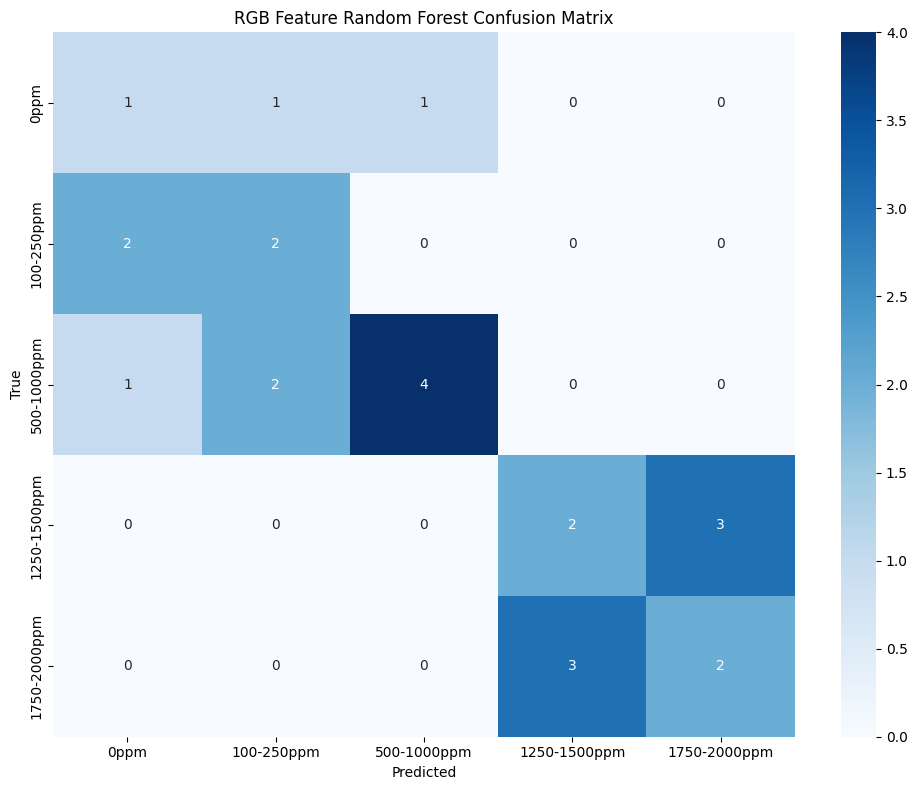

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

feature_columns = [col for col in rgb_df.columns if col not in ["filename", "kelas"]]
X = rgb_df[feature_columns].values
y_rgb_names = rgb_df["kelas"].apply(to_active_label)
y_rgb = y_rgb_names.map({name: index for index, name in enumerate(ACTIVE_CLASS_NAMES)}).values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_rgb, test_size=0.30, random_state=RANDOM_STATE, stratify=y_rgb
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ]
)

pipeline.fit(X_train, y_train)

val_acc = pipeline.score(X_val, y_val)
test_acc = pipeline.score(X_test, y_test)
print(f"Random Forest RGB baseline validation accuracy: {val_acc:.4f}")
print(f"Random Forest RGB baseline test accuracy: {test_acc:.4f}")

rf_pred = pipeline.predict(X_test)
print(classification_report(y_test, rf_pred, target_names=ACTIVE_CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_test, rf_pred, labels=list(range(len(ACTIVE_CLASS_NAMES))))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ACTIVE_CLASS_NAMES, yticklabels=ACTIVE_CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("RGB Feature Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


## 17. Simpan Model Terbaik

Model disimpan dalam format `.h5` agar bisa dipakai kembali oleh script prediksi.

In [40]:
# Simpan model dari memori dan juga salin checkpoint terbaik jika tersedia.
model.save(MODEL_OUTPUT)
print(f"Model saved to {MODEL_OUTPUT}")
print("Best validation checkpoint: best_borax_model.h5")

Model saved to borax_cnn_model.h5
Best validation checkpoint: best_borax_model.h5


## 18. Fungsi Prediksi Gambar Baru

Fungsi ini memuat model, melakukan segmentasi otomatis, resize, normalisasi, lalu mengembalikan label konsentrasi dan confidence.

In [34]:
def load_saved_model(model_path=MODEL_OUTPUT):
    return tf.keras.models.load_model(model_path)


def predict_image(image_path, loaded_model=None, model_path=MODEL_OUTPUT):
    if loaded_model is None:
        loaded_model = load_saved_model(model_path)

    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found or unreadable: {image_path}")

    crop_bgr = segment_curcumin_paper(image_bgr)
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    image_array = crop_rgb.astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    probs = loaded_model.predict(image_array, verbose=0)[0]
    pred_index = int(np.argmax(probs))
    return ACTIVE_CLASS_NAMES[pred_index], float(probs[pred_index])


# Contoh penggunaan setelah model tersimpan:
# label, confidence = predict_image("dataset/1250ppm/1250ppm_20260607_193346_246.jpg")
# print(label, confidence)